# 🔗 CLIP — Contrastive Language-Image Pre-Training
## A Visual Demo Notebook

**Paper:** Radford et al., OpenAI (2021) — [arxiv.org/abs/2103.00020](https://arxiv.org/abs/2103.00020)  
**Runtime:** CPU is fine · ~2 min total  
**Libraries:** NumPy, Matplotlib, scikit-learn, PyTorch (no GPU needed)

---

### What this notebook covers

| Section | Concept | Visual |
|---|---|---|
| 1 | What is CLIP? Big picture | Architecture diagram |
| 2 | Embedding space | What it means to embed text and images |
| 3 | The contrastive loss | The N×N similarity matrix |
| 4 | Training dynamics | How matched vs unmatched pairs evolve |
| 5 | Zero-shot classification | Query by text, retrieve by image |
| 6 | Embedding geometry | Cosine similarity and the unit sphere |

### The one-sentence idea

> CLIP trains two encoders — one for images, one for text — so that matching
> (image, caption) pairs end up **close together** in a shared vector space,
> and non-matching pairs end up **far apart**.
> Once trained, you can compare anything to anything — no retraining needed.


---
## Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
np.random.seed(42)
torch.manual_seed(42)
print('Ready ✅')


Ready ✅


---
## Section 1 — What Is CLIP?

CLIP has two separate encoders that share nothing except their training signal.

- The **image encoder** processes pixels → a fixed-size vector  
  *(in the real model: a Vision Transformer or ResNet)*
- The **text encoder** processes tokens → a fixed-size vector  
  *(in the real model: a Transformer)*

Both vectors are L2-normalised so they live on the **unit hypersphere** —  
cosine similarity between them is then simply their dot product.

The training data is 400 million (image, caption) pairs from the internet.  
No manual labels. No fixed set of classes. Just pairs.


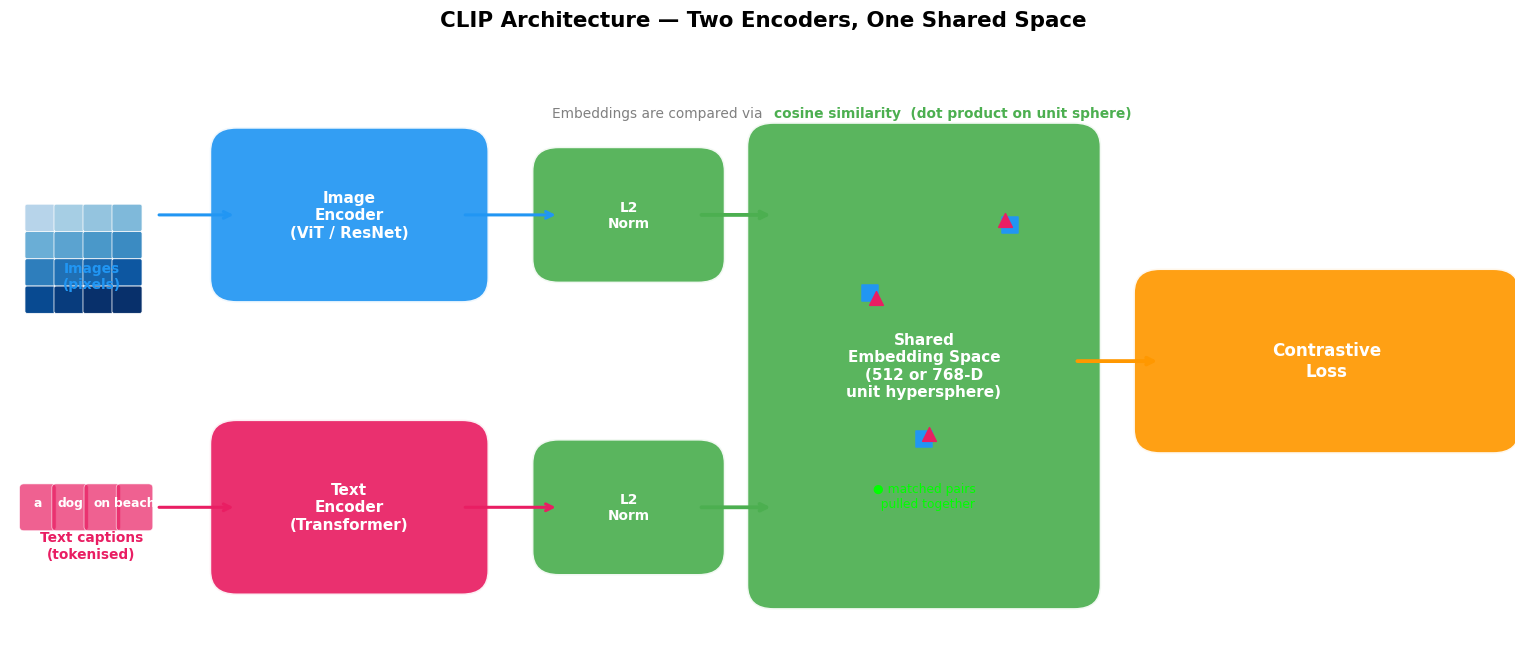

In [2]:
# ── Architecture diagram ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14); ax.set_ylim(0, 6)
ax.axis('off')

# ── colour palette ────────────────────────────────────────────────────────────
C_IMG  = '#2196F3'   # blue  — image side
C_TXT  = '#E91E63'   # pink  — text side
C_EMBD = '#4CAF50'   # green — shared embedding space
C_LOSS = '#FF9800'   # orange — contrastive loss

def box(x, y, w, h, label, color, fontsize=10, radius=0.25, alpha=0.92):
    rect = mpatches.FancyBboxPatch((x, y), w, h,
        boxstyle=f'round,pad={radius}', fc=color, ec='white', lw=2, alpha=alpha)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='white')

def arr(x1, y1, x2, y2, color='#555', lw=2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
        arrowprops=dict(arrowstyle='->', color=color, lw=lw))

# ── Image side ────────────────────────────────────────────────────────────────
# Images column (symbolic grid)
for row in range(4):
    for col in range(4):
        shade = 0.3 + (row*4+col)/20
        rect = mpatches.FancyBboxPatch((0.15+col*0.27, 4.15-row*0.28), 0.24, 0.24,
            boxstyle='round,pad=0.02', fc=plt.cm.Blues(shade), ec='white', lw=0.5)
        ax.add_patch(rect)
ax.text(0.75, 3.55, 'Images\n(pixels)', ha='center', fontsize=9,
        color=C_IMG, fontweight='bold')

arr(1.35, 4.3, 2.1, 4.3, C_IMG)
box(2.1, 3.65, 2.1, 1.3, 'Image\nEncoder\n(ViT / ResNet)', C_IMG, fontsize=10)
arr(4.2, 4.3, 5.1, 4.3, C_IMG)
box(5.1, 3.85, 1.3, 0.9, 'L2\nNorm', C_EMBD, fontsize=9)
arr(6.4, 4.3, 7.1, 4.3, C_EMBD, lw=2.5)

# ── Text side ────────────────────────────────────────────────────────────────
# Text tokens
tokens = ['a', 'dog', 'on', 'beach']
for k, tok in enumerate(tokens):
    rect = mpatches.FancyBboxPatch((0.12+k*0.3, 1.1), 0.26, 0.4,
        boxstyle='round,pad=0.04', fc=C_TXT, ec='white', lw=0.5, alpha=0.7)
    ax.add_patch(rect)
    ax.text(0.25+k*0.3, 1.31, tok, ha='center', fontsize=8, color='white', fontweight='bold')
ax.text(0.75, 0.78, 'Text captions\n(tokenised)', ha='center', fontsize=9,
        color=C_TXT, fontweight='bold')

arr(1.35, 1.3, 2.1, 1.3, C_TXT)
box(2.1, 0.65, 2.1, 1.3, 'Text\nEncoder\n(Transformer)', C_TXT, fontsize=10)
arr(4.2, 1.3, 5.1, 1.3, C_TXT)
box(5.1, 0.85, 1.3, 0.9, 'L2\nNorm', C_EMBD, fontsize=9)
arr(6.4, 1.3, 7.1, 1.3, C_EMBD, lw=2.5)

# ── Shared embedding space ────────────────────────────────────────────────────
box(7.1, 0.5, 2.8, 4.5, 'Shared\nEmbedding Space\n(512 or 768-D\nunit hypersphere)',
    C_EMBD, fontsize=10)

# matched/unmatched dots
ax.scatter([8.0, 8.5, 9.3], [3.5, 2.0, 4.2], s=120, c=C_IMG,
           zorder=5, marker='s', label='image emb')
ax.scatter([8.05, 8.55, 9.25], [3.45, 2.05, 4.25], s=80, c=C_TXT,
           zorder=5, marker='^', label='text emb')
for xi, yi, xt, yt in [(8.0,3.5,8.05,3.45),(8.5,2.0,8.55,2.05),(9.3,4.2,9.25,4.25)]:
    ax.plot([xi,xt],[yi,yt], color='lime', lw=2, zorder=4)
ax.text(8.5, 1.3, '● matched pairs\n  pulled together', ha='center',
        fontsize=8, color='lime')

arr(9.9, 2.8, 10.7, 2.8, C_LOSS, lw=2.5)
box(10.7, 2.1, 3.1, 1.4, 'Contrastive\nLoss', C_LOSS, fontsize=11)

# ── Labels ────────────────────────────────────────────────────────────────────
ax.text(7.0, 5.3, 'Embeddings are compared via', ha='right', fontsize=9, color='gray')
ax.text(7.1, 5.3, 'cosine similarity  (dot product on unit sphere)',
        ha='left', fontsize=9, color=C_EMBD, fontweight='bold')

ax.set_title('CLIP Architecture — Two Encoders, One Shared Space',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()


---
## Section 2 — What Is an Embedding?

An **embedding** is a fixed-size vector of numbers that represents the *meaning* of an input.  
Similar inputs → vectors that point in similar directions.

CLIP's embeddings are **L2-normalised** — every vector has length 1.  
They all live on the surface of a high-dimensional unit sphere.  
Similarity is measured by the **angle** between them (cosine similarity = dot product).

Below we simulate toy 2-D embeddings for 5 semantic categories  
and show how images and captions of the same concept cluster together.


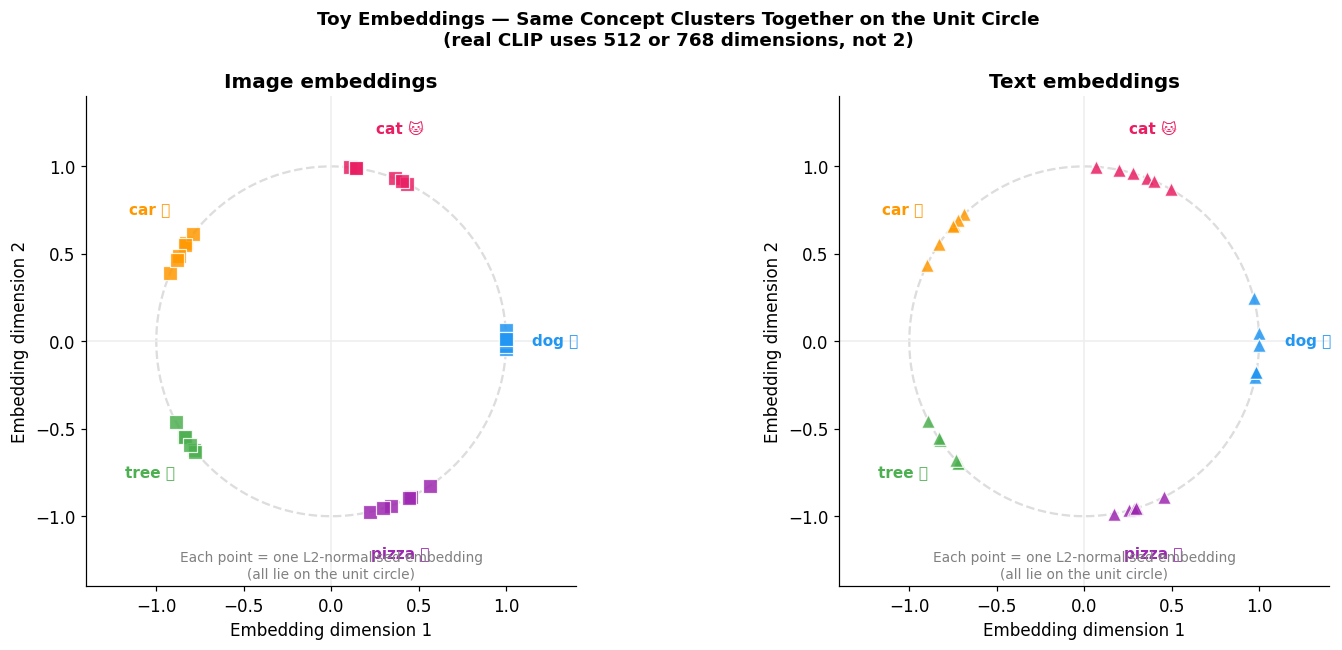

Observation: same-category image and text embeddings point in the same direction.
Different categories point in different directions — that is the goal of training.


In [3]:
# ── Toy embeddings: 5 categories, 2D for easy visualisation ──────────────────
CATEGORIES = ['dog 🐶', 'cat 🐱', 'car 🚗', 'tree 🌳', 'pizza 🍕']
N_CAT = len(CATEGORIES)
N_PER = 6      # samples per category

# Place category centres evenly around the unit circle
angles_centre = np.linspace(0, 2*np.pi, N_CAT, endpoint=False)
centres = np.stack([np.cos(angles_centre), np.sin(angles_centre)], axis=1)  # (5,2)

# Generate image and text embeddings with small within-category noise
np.random.seed(7)
NOISE = 0.12

img_embs, txt_embs, cat_ids = [], [], []
for k, centre in enumerate(centres):
    for _ in range(N_PER):
        ie = centre + np.random.randn(2) * NOISE
        te = centre + np.random.randn(2) * NOISE
        img_embs.append(ie / np.linalg.norm(ie))   # L2 normalise → unit circle
        txt_embs.append(te / np.linalg.norm(te))
        cat_ids.append(k)

img_embs = np.array(img_embs)   # (N_CAT*N_PER, 2)
txt_embs = np.array(txt_embs)
cat_ids  = np.array(cat_ids)

# ── Plot ──────────────────────────────────────────────────────────────────────
palette = ['#2196F3','#E91E63','#FF9800','#4CAF50','#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_i, (embs, marker, label) in enumerate([
        (img_embs, 's', 'Image embeddings'),
        (txt_embs, '^', 'Text embeddings')]):
    ax = axes[ax_i]
    # Draw unit circle
    theta_c = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(theta_c), np.sin(theta_c), color='#ddd', lw=1.5, ls='--', zorder=0)
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4); ax.set_aspect('equal')

    for k in range(N_CAT):
        mask = cat_ids == k
        ax.scatter(embs[mask, 0], embs[mask, 1],
                   s=80, color=palette[k], marker=marker, alpha=0.85,
                   edgecolors='white', lw=0.8, zorder=3)
        # Label at cluster centre
        cx, cy = centres[k]
        ax.text(cx * 1.28, cy * 1.28, CATEGORIES[k],
                ha='center', va='center', fontsize=10, fontweight='bold',
                color=palette[k])

    ax.axhline(0, color='#eee', lw=1); ax.axvline(0, color='#eee', lw=1)
    ax.set_title(label, fontweight='bold', fontsize=13)
    ax.set_xlabel('Embedding dimension 1')
    ax.set_ylabel('Embedding dimension 2')
    ax.text(0, -1.35, 'Each point = one L2-normalised embedding\n(all lie on the unit circle)',
            ha='center', fontsize=9, color='gray')

plt.suptitle('Toy Embeddings — Same Concept Clusters Together on the Unit Circle\n'
             '(real CLIP uses 512 or 768 dimensions, not 2)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('Observation: same-category image and text embeddings point in the same direction.')
print('Different categories point in different directions — that is the goal of training.')


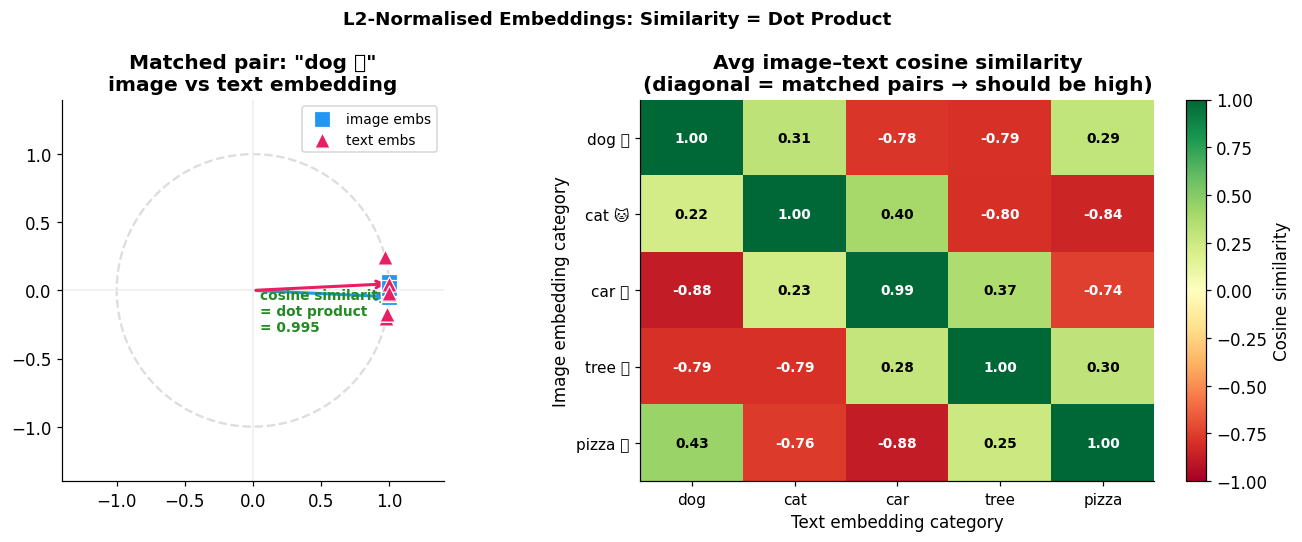

In [4]:
# ── Show that after L2-norm, similarity = dot product ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: show image + text embeddings overlaid for one category
ax = axes[0]
theta_c = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta_c), np.sin(theta_c), color='#ddd', lw=1.5, ls='--')

k_show = 0   # 'dog'
mask = cat_ids == k_show
ax.scatter(img_embs[mask,0], img_embs[mask,1], s=100, color=C_IMG, marker='s',
           label='image embs', edgecolors='white', lw=0.8, zorder=4)
ax.scatter(txt_embs[mask,0], txt_embs[mask,1], s=100, color=C_TXT, marker='^',
           label='text embs',  edgecolors='white', lw=0.8, zorder=4)

# Draw one matched pair with an angle arc
ie, te = img_embs[mask][0], txt_embs[mask][0]
ax.annotate('', xy=ie, xytext=(0,0),
    arrowprops=dict(arrowstyle='->', color=C_IMG, lw=2))
ax.annotate('', xy=te, xytext=(0,0),
    arrowprops=dict(arrowstyle='->', color=C_TXT, lw=2))
dot = float(np.dot(ie, te))
ax.text(0.05, -0.3, f'cosine similarity\n= dot product\n= {dot:.3f}',
        fontsize=9, color='forestgreen', fontweight='bold')

ax.set_xlim(-1.4,1.4); ax.set_ylim(-1.4,1.4); ax.set_aspect('equal')
ax.set_title(f'Matched pair: "{CATEGORIES[k_show]}"\nimage vs text embedding',
             fontweight='bold')
ax.legend(fontsize=9); ax.axhline(0,color='#eee',lw=1); ax.axvline(0,color='#eee',lw=1)

# Right: similarity heatmap across all category pairs (averaged)
ax2 = axes[1]
sim_matrix = np.zeros((N_CAT, N_CAT))
for ki in range(N_CAT):
    for kj in range(N_CAT):
        ie_mean = img_embs[cat_ids==ki].mean(axis=0)
        te_mean = txt_embs[cat_ids==kj].mean(axis=0)
        sim_matrix[ki, kj] = np.dot(
            ie_mean / np.linalg.norm(ie_mean),
            te_mean / np.linalg.norm(te_mean))

im = ax2.imshow(sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax2, label='Cosine similarity')
labels_short = [c.split()[0] for c in CATEGORIES]
ax2.set_xticks(range(N_CAT)); ax2.set_xticklabels(labels_short, fontsize=10)
ax2.set_yticks(range(N_CAT)); ax2.set_yticklabels(CATEGORIES, fontsize=10)
ax2.set_xlabel('Text embedding category')
ax2.set_ylabel('Image embedding category')
for i in range(N_CAT):
    for j in range(N_CAT):
        ax2.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                 fontsize=9, fontweight='bold',
                 color='white' if abs(sim_matrix[i,j]) > 0.5 else 'black')
ax2.set_title('Avg image–text cosine similarity\n(diagonal = matched pairs → should be high)',
              fontweight='bold')

plt.suptitle('L2-Normalised Embeddings: Similarity = Dot Product',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Section 3 — The Contrastive Loss

Given a batch of $N$ (image, text) pairs, CLIP builds an **$N \times N$ similarity matrix**:

$$S_{ij} = \frac{\mathbf{v}_i \cdot \mathbf{t}_j}{\tau}$$

where $\mathbf{v}_i$ is the image embedding, $\mathbf{t}_j$ is the text embedding,  
and $\tau$ is a learned temperature parameter.

The **diagonal** entries $S_{ii}$ are the matched pairs.  
The loss pushes the diagonal to be high and everything else low — simultaneously in both directions:

$$\mathcal{L} = \frac{1}{2}\left[\underbrace{\frac{1}{N}\sum_i \text{CE}(S_i^\text{row},\, i)}_{\text{image→text}} + \underbrace{\frac{1}{N}\sum_j \text{CE}(S_j^\text{col},\, j)}_{\text{text→image}}\right]$$

This is standard **cross-entropy applied twice** — once per direction.  
It is equivalent to treating each row (or column) as a $N$-way classification problem.


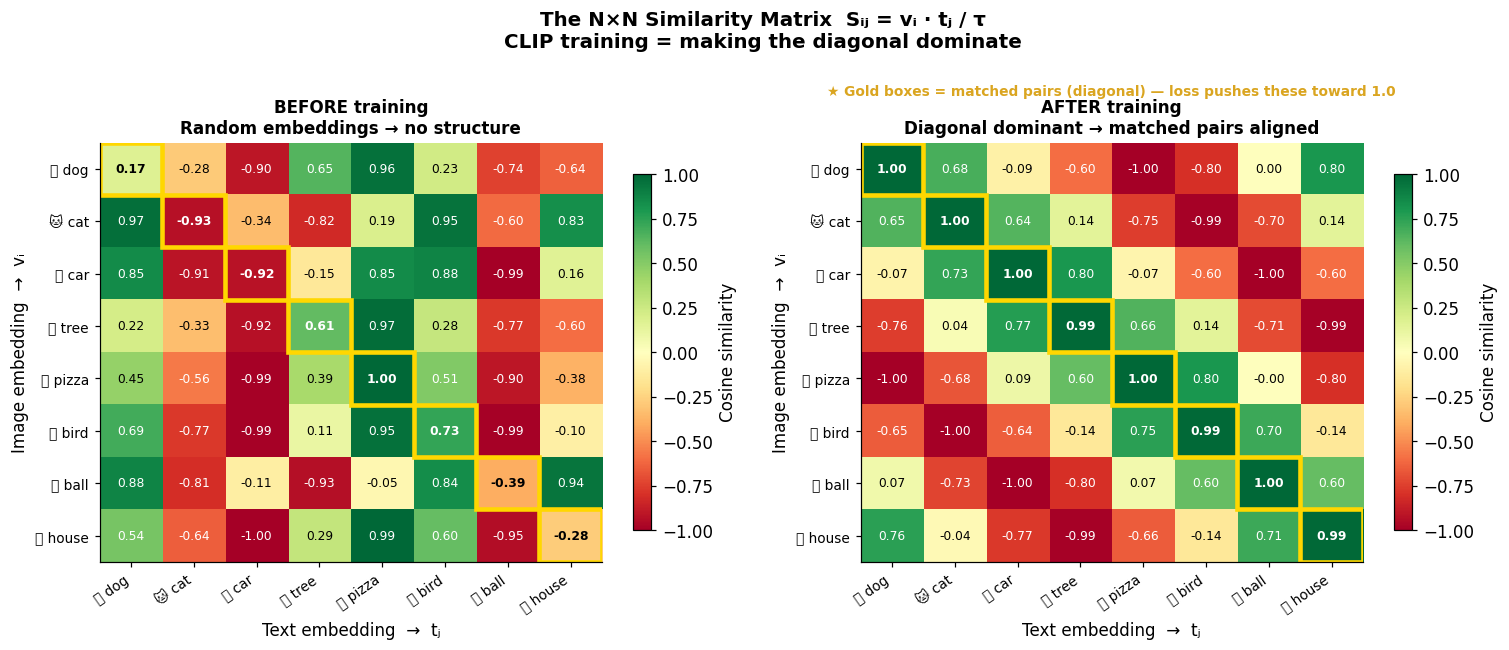

In [5]:
# ── The N×N similarity matrix — before and after training ─────────────────────
N_BATCH = 8    # batch size for illustration

# Simulate BEFORE training: random embeddings → random similarity matrix
np.random.seed(1)
v_rand = np.random.randn(N_BATCH, 2)
t_rand = np.random.randn(N_BATCH, 2)
v_rand /= np.linalg.norm(v_rand, axis=1, keepdims=True)
t_rand /= np.linalg.norm(t_rand, axis=1, keepdims=True)
S_before = v_rand @ t_rand.T   # (N, N) cosine similarities

# Simulate AFTER training: matched pairs cluster, diagonal dominant
# Place embeddings close together for matched pairs
angle_base = np.linspace(0, 2*np.pi, N_BATCH, endpoint=False)
v_after = np.stack([np.cos(angle_base), np.sin(angle_base)], axis=1)
t_after = v_after + np.random.randn(N_BATCH, 2) * 0.08
v_after /= np.linalg.norm(v_after, axis=1, keepdims=True)
t_after /= np.linalg.norm(t_after, axis=1, keepdims=True)
S_after = v_after @ t_after.T

# ── Figure: before / after ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

item_labels = ['🐶 dog', '🐱 cat', '🚗 car', '🌳 tree',
               '🍕 pizza', '🐦 bird', '⚽ ball', '🏠 house']

for ax, S, title, note in [
    (axes[0], S_before, 'BEFORE training', 'Random embeddings → no structure'),
    (axes[1], S_after,  'AFTER training',  'Diagonal dominant → matched pairs aligned')]:

    im = ax.imshow(S, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, label='Cosine similarity', shrink=0.85)

    ax.set_xticks(range(N_BATCH)); ax.set_xticklabels(item_labels, rotation=35,
                                                       ha='right', fontsize=9)
    ax.set_yticks(range(N_BATCH)); ax.set_yticklabels(item_labels, fontsize=9)
    ax.set_xlabel('Text embedding  →  tⱼ')
    ax.set_ylabel('Image embedding  →  vᵢ')

    for i in range(N_BATCH):
        for j in range(N_BATCH):
            val = S[i, j]
            weight = 'bold' if i == j else 'normal'
            color  = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, fontweight=weight, color=color)

    # Highlight diagonal with gold boxes
    for d in range(N_BATCH):
        rect = plt.Rectangle((d-0.5, d-0.5), 1, 1,
                              fill=False, edgecolor='gold', lw=3)
        ax.add_patch(rect)

    ax.set_title(f'{title}\n{note}', fontweight='bold', fontsize=11)

axes[1].text(N_BATCH/2 - 0.5, -1.4,
             '★ Gold boxes = matched pairs (diagonal) — loss pushes these toward 1.0',
             ha='center', fontsize=9, color='goldenrod', fontweight='bold')

plt.suptitle('The N×N Similarity Matrix  Sᵢⱼ = vᵢ · tⱼ / τ\n'
             'CLIP training = making the diagonal dominate',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Section 4 — Training Dynamics

Let's train a toy CLIP model and watch how the similarity matrix evolves.

Our toy setup:
- **5 semantic categories** (dog, cat, car, tree, pizza)
- **Toy encoders**: small MLPs that map hand-crafted feature vectors → 8-D embeddings
- **Contrastive loss**: symmetric cross-entropy on the similarity matrix

We will track:
1. The training loss
2. The mean similarity of matched pairs (diagonal) vs unmatched pairs (off-diagonal)
3. The similarity matrix at three stages of training


In [6]:
# ── Toy dataset: 5 categories, distinct feature vectors with noise ────────────
N_PAIRS   = 200
N_CATS    = 5
IMG_DIM   = 12    # image feature dim
TXT_DIM   = 10    # text feature dim
EMBED_DIM = 8     # shared embedding dim

np.random.seed(42)
img_feats_all, txt_feats_all, labels_all = [], [], []

for pair_i in range(N_PAIRS):
    cat = pair_i % N_CATS
    # Image features: strong signal in 2 specific dims, rest noise
    img_f  = np.random.randn(IMG_DIM) * 0.4
    img_f[cat*2 : cat*2+2] += 2.5
    # Text features: strong signal in 2 specific dims (slightly different), rest noise
    txt_f  = np.random.randn(TXT_DIM) * 0.4
    txt_f[cat*2 : cat*2+2] += 2.5
    img_feats_all.append(img_f)
    txt_feats_all.append(txt_f)
    labels_all.append(cat)

img_feats = torch.FloatTensor(np.array(img_feats_all))
txt_feats = torch.FloatTensor(np.array(txt_feats_all))
labels    = np.array(labels_all)

print(f'Dataset: {N_PAIRS} (image, text) pairs across {N_CATS} categories')
print(f'Image feature dim: {IMG_DIM}  |  Text feature dim: {TXT_DIM}  |  Embed dim: {EMBED_DIM}')


Dataset: 200 (image, text) pairs across 5 categories
Image feature dim: 12  |  Text feature dim: 10  |  Embed dim: 8


In [7]:
# ── Toy encoder networks ──────────────────────────────────────────────────────
class ToyEncoder(nn.Module):
    def __init__(self, in_dim, embed_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32), nn.ReLU(),
            nn.Linear(32, embed_dim)
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)   # L2 normalise → unit sphere


def clip_loss(img_emb, txt_emb, temp=0.07):
    '''Symmetric cross-entropy contrastive loss.
    img_emb, txt_emb: (N, embed_dim) L2-normalised
    Diagonal of the NxN similarity matrix = matched pairs.
    '''
    logits = (img_emb @ txt_emb.T) / temp    # (N, N)
    N      = logits.shape[0]
    labels = torch.arange(N)                  # correct match = diagonal index
    loss_i2t = F.cross_entropy(logits,   labels)   # image→text direction
    loss_t2i = F.cross_entropy(logits.T, labels)   # text→image direction
    return (loss_i2t + loss_t2i) / 2


img_enc = ToyEncoder(IMG_DIM, EMBED_DIM)
txt_enc = ToyEncoder(TXT_DIM, EMBED_DIM)
opt     = torch.optim.Adam(
    list(img_enc.parameters()) + list(txt_enc.parameters()), lr=1e-2)

print(f'Image encoder params: {sum(p.numel() for p in img_enc.parameters()):,}')
print(f'Text  encoder params: {sum(p.numel() for p in txt_enc.parameters()):,}')


Image encoder params: 680
Text  encoder params: 616


In [8]:
# ── Training loop: track loss, matched/unmatched similarity, matrix snapshots ──
N_STEPS   = 600
BATCH     = 40
TEMP      = 0.07
SNAP_AT   = [0, 100, 600]   # record similarity matrix at these steps

loss_hist, diag_hist, offdiag_hist = [], [], []
matrix_snaps = {}

for step in range(N_STEPS + 1):
    idx      = torch.randperm(N_PAIRS)[:BATCH]
    ie       = img_enc(img_feats[idx])
    te       = txt_enc(txt_feats[idx])
    loss     = clip_loss(ie, te, TEMP)

    if step < N_STEPS:
        opt.zero_grad(); loss.backward(); opt.step()

    loss_hist.append(loss.item())

    # Track full-dataset similarity matrix
    with torch.no_grad():
        all_ie  = img_enc(img_feats)
        all_te  = txt_enc(txt_feats)
        sim_all = (all_ie @ all_te.T).numpy()   # (N_PAIRS, N_PAIRS)
        diag_hist.append(np.diag(sim_all).mean())
        mask_off = ~np.eye(N_PAIRS, dtype=bool)
        offdiag_hist.append(sim_all[mask_off].mean())
        if step in SNAP_AT:
            matrix_snaps[step] = sim_all.copy()

    if step % 200 == 0:
        print(f'step {step:4d}  loss={loss.item():.4f}  '
              f'diag={diag_hist[-1]:.3f}  off-diag={offdiag_hist[-1]:.3f}')

print('Training complete ✓')


step    0  loss=8.8118  diag=0.138  off-diag=0.054
step  200  loss=1.2285  diag=0.845  off-diag=0.003
step  400  loss=0.4822  diag=0.850  off-diag=-0.009
step  600  loss=0.2903  diag=0.878  off-diag=-0.006
Training complete ✓


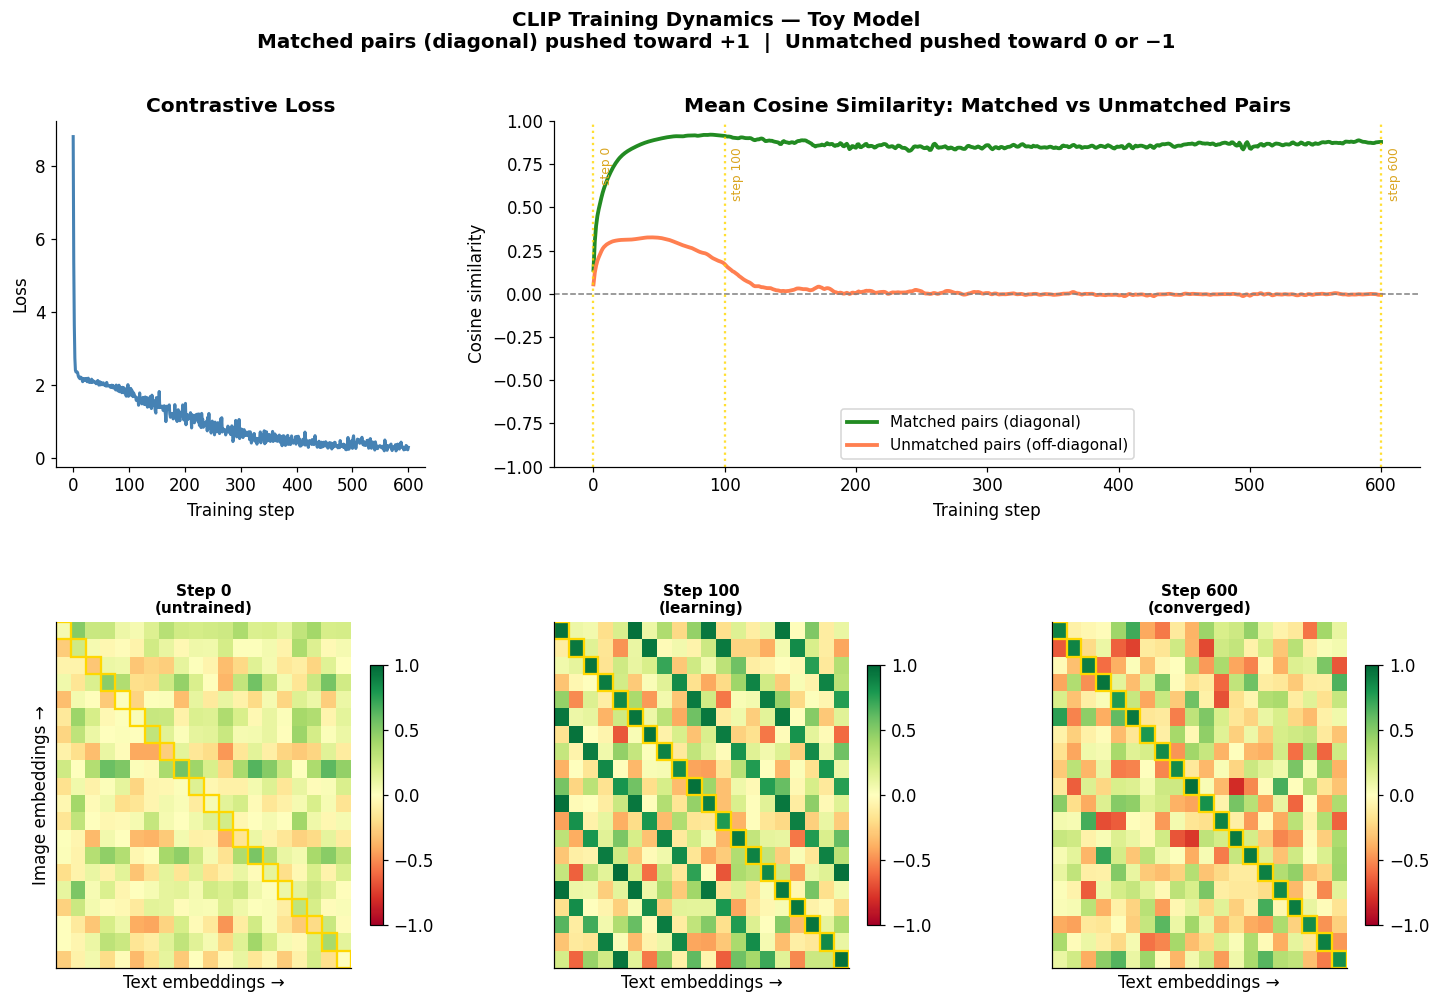

Final diagonal mean:     0.878  (target: close to +1.0)
Final off-diagonal mean: -0.006  (target: close to 0 or negative)


In [9]:
# ── Plot training dynamics ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Row 0: loss + diag/offdiag curves ─────────────────────────────────────────
ax_loss = fig.add_subplot(gs[0, 0])
ax_loss.plot(loss_hist, color='steelblue', lw=2)
ax_loss.set_title('Contrastive Loss', fontweight='bold')
ax_loss.set_xlabel('Training step'); ax_loss.set_ylabel('Loss')

ax_sim = fig.add_subplot(gs[0, 1:3])
ax_sim.plot(diag_hist,    color='forestgreen', lw=2.5, label='Matched pairs (diagonal)')
ax_sim.plot(offdiag_hist, color='coral',       lw=2.5, label='Unmatched pairs (off-diagonal)')
ax_sim.axhline(0, color='gray', lw=1, ls='--')
for snap_step in SNAP_AT:
    ax_sim.axvline(snap_step, color='gold', lw=1.5, ls=':', alpha=0.8)
    ax_sim.text(snap_step+5, 0.85, f'step {snap_step}',
                fontsize=8, color='goldenrod', rotation=90, va='top')
ax_sim.set_title('Mean Cosine Similarity: Matched vs Unmatched Pairs', fontweight='bold')
ax_sim.set_xlabel('Training step'); ax_sim.set_ylabel('Cosine similarity')
ax_sim.legend(fontsize=10); ax_sim.set_ylim(-1, 1)

# ── Row 1: similarity matrix snapshots ────────────────────────────────────────
snap_titles = {0:'Step 0\n(untrained)',
               100:'Step 100\n(learning)',
               600:'Step 600\n(converged)'}

for col, step in enumerate(SNAP_AT):
    ax = fig.add_subplot(gs[1, col])
    # Show only a 20×20 sub-block for clarity
    sub = matrix_snaps[step][:20, :20]
    im  = ax.imshow(sub, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.75)
    # Gold diagonal boxes
    for d in range(20):
        ax.add_patch(plt.Rectangle((d-0.5,d-0.5),1,1,
                     fill=False, edgecolor='gold', lw=1.5))
    ax.set_title(snap_titles[step], fontweight='bold', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('Text embeddings →')
    if col == 0: ax.set_ylabel('Image embeddings →')

plt.suptitle('CLIP Training Dynamics — Toy Model\n'
             'Matched pairs (diagonal) pushed toward +1  |  Unmatched pushed toward 0 or −1',
             fontsize=13, fontweight='bold')
plt.show()

print(f'Final diagonal mean:     {diag_hist[-1]:.3f}  (target: close to +1.0)')
print(f'Final off-diagonal mean: {offdiag_hist[-1]:.3f}  (target: close to 0 or negative)')


---
## Section 5 — Zero-Shot Classification

The most remarkable property of CLIP: once trained, you can classify images  
**without any task-specific training**.

### How it works

```
1. Write text prompts for each class:
   'a photo of a dog', 'a photo of a cat', 'a photo of a car', ...

2. Encode all prompts → text embeddings  (one per class)

3. Encode the query image → image embedding

4. Compute cosine similarity between the image and every text prompt

5. Apply softmax → probability distribution over classes

6. Predicted class = highest probability
```

No fine-tuning. No labelled examples for the new task. Just text prompts.

This is called **zero-shot** because the model has seen zero labelled examples  
of the target task during task-specific training.


In [10]:
# ── Simulate zero-shot classification with the trained toy encoders ────────────
CAT_NAMES = ['dog', 'cat', 'car', 'tree', 'pizza']

img_enc.eval(); txt_enc.eval()

with torch.no_grad():
    # Compute text embeddings for each class prompt
    # In toy setup: text feature = one-hot-like vector for the class
    class_txt_feats = []
    for cat in range(N_CATS):
        f = np.zeros(TXT_DIM)
        f[cat*2:cat*2+2] = 2.5              # the clean class signal
        class_txt_feats.append(f)
    class_txt_t   = torch.FloatTensor(np.array(class_txt_feats))
    class_txt_emb = txt_enc(class_txt_t)    # (N_CATS, EMBED_DIM) — the 'text prompts'

    # Run zero-shot on 25 test images (5 per category)
    test_correct, test_results = 0, []
    for cat in range(N_CATS):
        for sample in range(5):
            f = np.random.randn(IMG_DIM) * 0.4
            f[cat*2:cat*2+2] += 2.5
            img_t   = torch.FloatTensor(f[None])
            img_emb = img_enc(img_t)          # (1, EMBED_DIM)
            sims    = (img_emb @ class_txt_emb.T).squeeze().numpy()   # (N_CATS,)
            probs   = np.exp(sims / 0.07)
            probs  /= probs.sum()
            pred    = int(np.argmax(probs))
            correct = (pred == cat)
            if correct: test_correct += 1
            test_results.append({'true': cat, 'pred': pred,
                                  'probs': probs, 'correct': correct})

print(f'Zero-shot accuracy: {test_correct}/25  ({test_correct/25*100:.0f}%)')


Zero-shot accuracy: 20/25  (80%)


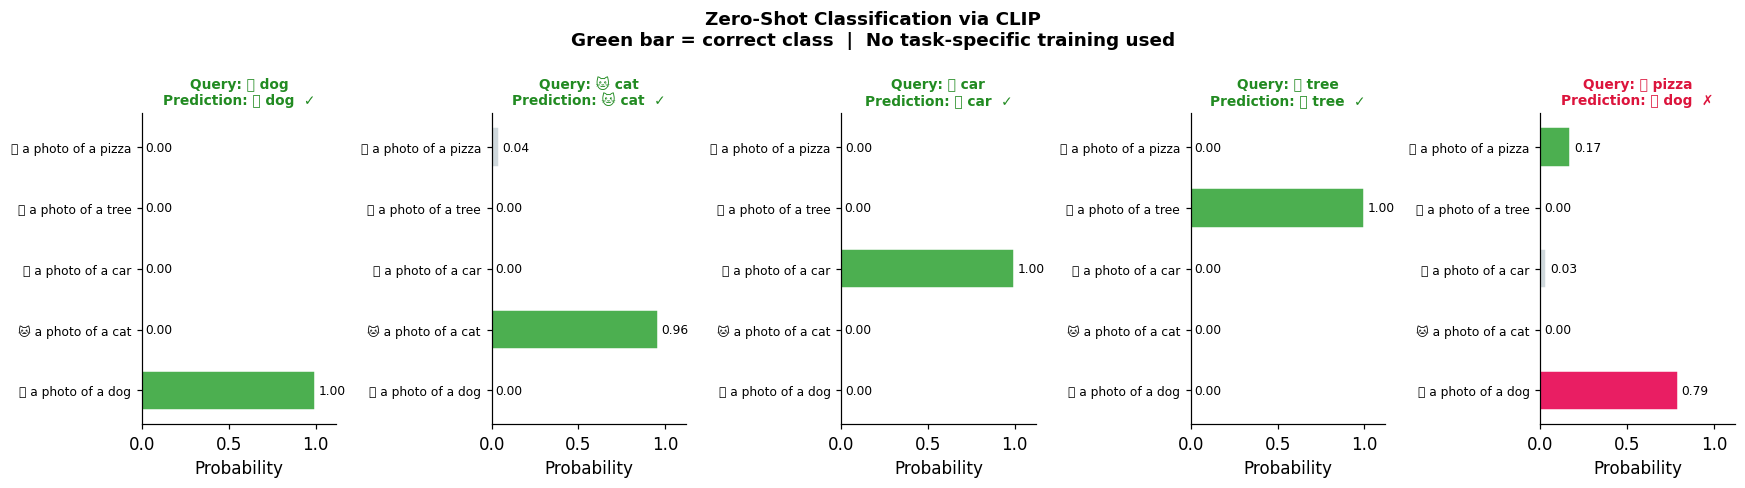

In [11]:
# ── Visualise zero-shot: probability bars for 5 query images ──────────────────
CAT_EMOJIS = ['🐶','🐱','🚗','🌳','🍕']
PROMPTS    = [f'a photo of a {c}' for c in CAT_NAMES]

# Pick one example per category to display
display_idx = [k * 5 for k in range(N_CATS)]

fig, axes = plt.subplots(1, N_CATS, figsize=(16, 4.5))

for col, idx in enumerate(display_idx):
    r    = test_results[idx]
    ax   = axes[col]
    true_cat = r['true']
    pred_cat = r['pred']
    probs    = r['probs']

    colors = ['#4CAF50' if k == true_cat
              else '#E91E63' if k == pred_cat and pred_cat != true_cat
              else '#CFD8DC'
              for k in range(N_CATS)]

    bars = ax.barh(range(N_CATS), probs, color=colors, edgecolor='white', height=0.65)
    ax.set_yticks(range(N_CATS))
    ax.set_yticklabels([f'{CAT_EMOJIS[k]} {PROMPTS[k]}' for k in range(N_CATS)],
                        fontsize=8)
    ax.set_xlim(0, 1.12)
    ax.set_xlabel('Probability')

    for bar, prob in zip(bars, probs):
        ax.text(prob + 0.02, bar.get_y() + bar.get_height()/2,
                f'{prob:.2f}', va='center', fontsize=8)

    tick = '✓' if r['correct'] else '✗'
    title_color = 'forestgreen' if r['correct'] else 'crimson'
    ax.set_title(f'Query: {CAT_EMOJIS[true_cat]} {CAT_NAMES[true_cat]}\n'
                 f'Prediction: {CAT_EMOJIS[pred_cat]} {CAT_NAMES[pred_cat]}  {tick}',
                 fontweight='bold', fontsize=9, color=title_color)

plt.suptitle('Zero-Shot Classification via CLIP\n'
             'Green bar = correct class  |  No task-specific training used',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Section 6 — Embedding Geometry

Let's look at where image and text embeddings actually sit after training —  
using PCA to project the 8-D embeddings down to 2-D for visualisation.

A well-trained model should show:
- **Image and text embeddings of the same category** sitting close together
- **Different categories** clearly separated
- Text and image embeddings interleaved (not in two separate clouds)


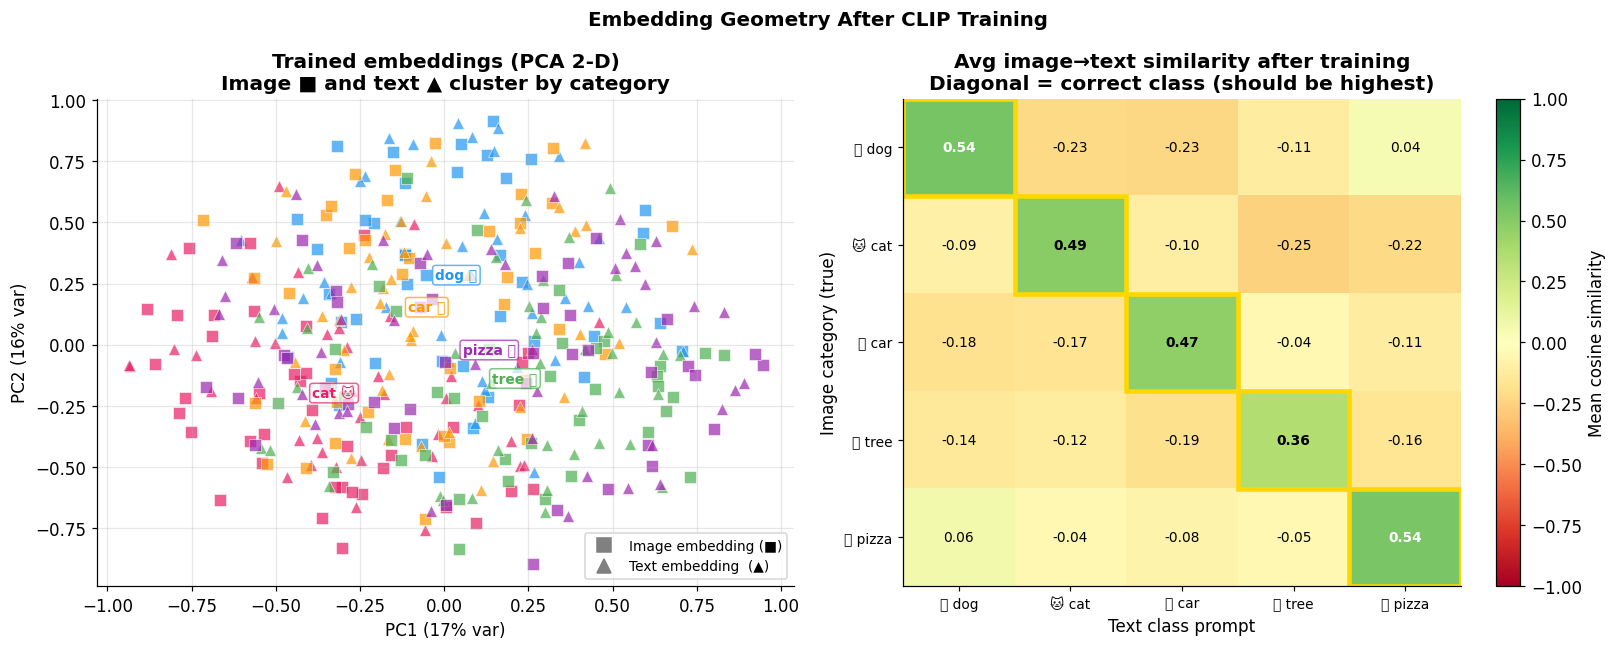

Diagonal values (image category → correct text prompt):
  🐶 dog   : sim=0.543  (rank 1 of 5)
  🐱 cat   : sim=0.489  (rank 1 of 5)
  🚗 car   : sim=0.468  (rank 1 of 5)
  🌳 tree  : sim=0.357  (rank 1 of 5)
  🍕 pizza : sim=0.536  (rank 1 of 5)


In [12]:
# ── PCA of trained embeddings ─────────────────────────────────────────────────
img_enc.eval(); txt_enc.eval()

with torch.no_grad():
    all_ie = img_enc(img_feats).numpy()   # (N_PAIRS, EMBED_DIM)
    all_te = txt_enc(txt_feats).numpy()

# PCA on the combined set
combined = np.vstack([all_ie, all_te])           # (2*N_PAIRS, EMBED_DIM)
pca      = PCA(n_components=2)
proj     = pca.fit_transform(combined)            # (2*N_PAIRS, 2)
ie_2d    = proj[:N_PAIRS]
te_2d    = proj[N_PAIRS:]

palette  = ['#2196F3','#E91E63','#FF9800','#4CAF50','#9C27B0']
CAT_NAMES_FULL = ['dog 🐶','cat 🐱','car 🚗','tree 🌳','pizza 🍕']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: image and text embeddings overlaid ──────────────────────────────────
ax = axes[0]
for k in range(N_CATS):
    mask = labels == k
    ax.scatter(ie_2d[mask,0], ie_2d[mask,1], s=60, color=palette[k],
               marker='s', alpha=0.7, edgecolors='white', lw=0.5,
               label=f'{CAT_NAMES_FULL[k]} — image' if k==0 else '_')
    ax.scatter(te_2d[mask,0], te_2d[mask,1], s=60, color=palette[k],
               marker='^', alpha=0.7, edgecolors='white', lw=0.5,
               label=f'{CAT_NAMES_FULL[k]} — text' if k==0 else '_')
    # Cluster label
    cx = np.concatenate([ie_2d[mask,0], te_2d[mask,0]]).mean()
    cy = np.concatenate([ie_2d[mask,1], te_2d[mask,1]]).mean()
    ax.text(cx, cy, CAT_NAMES_FULL[k], fontsize=9, fontweight='bold',
            color=palette[k], ha='center',
            bbox=dict(fc='white', ec=palette[k], alpha=0.7, boxstyle='round,pad=0.2'))

# Legend for markers
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], marker='s', color='gray', ls='none', ms=9, label='Image embedding (■)'),
    Line2D([0],[0], marker='^', color='gray', ls='none', ms=9, label='Text embedding  (▲)'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')
ax.set_title('Trained embeddings (PCA 2-D)\nImage ■ and text ▲ cluster by category',
             fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% var)')
ax.grid(True, alpha=0.3)

# ── Right: cosine similarity between every image and every class text prompt ───
ax2 = axes[1]
with torch.no_grad():
    class_te = txt_enc(class_txt_t).numpy()   # (N_CATS, EMBED_DIM)
    sim_final = all_ie @ class_te.T           # (N_PAIRS, N_CATS)

# Average per true category
avg_sim = np.zeros((N_CATS, N_CATS))
for ki in range(N_CATS):
    for kj in range(N_CATS):
        avg_sim[ki, kj] = sim_final[labels==ki, kj].mean()

im2 = ax2.imshow(avg_sim, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im2, ax=ax2, label='Mean cosine similarity')
short = [c.split()[0] for c in CAT_NAMES_FULL]
ax2.set_xticks(range(N_CATS)); ax2.set_xticklabels([f'{CAT_EMOJIS[k]} {short[k]}' for k in range(N_CATS)], fontsize=9)
ax2.set_yticks(range(N_CATS)); ax2.set_yticklabels([f'{CAT_EMOJIS[k]} {short[k]}' for k in range(N_CATS)], fontsize=9)
ax2.set_xlabel('Text class prompt'); ax2.set_ylabel('Image category (true)')
for i in range(N_CATS):
    for j in range(N_CATS):
        ax2.text(j, i, f'{avg_sim[i,j]:.2f}', ha='center', va='center',
                 fontsize=9, fontweight='bold' if i==j else 'normal',
                 color='white' if abs(avg_sim[i,j]) > 0.5 else 'black')
for d in range(N_CATS):
    ax2.add_patch(plt.Rectangle((d-0.5,d-0.5),1,1,fill=False,edgecolor='gold',lw=3))
ax2.set_title('Avg image→text similarity after training\nDiagonal = correct class (should be highest)',
              fontweight='bold')

plt.suptitle('Embedding Geometry After CLIP Training',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Diagonal values (image category → correct text prompt):')
for k in range(N_CATS):
    row = avg_sim[k]
    rank = N_CATS - np.searchsorted(np.sort(row), row[k])
    print(f'  {CAT_EMOJIS[k]} {CAT_NAMES[k]:6s}: sim={row[k]:.3f}  (rank {rank} of {N_CATS})')


---
## Summary

| Concept | Key idea |
|---|---|
| **Two encoders** | One for images (ViT/ResNet), one for text (Transformer) — no shared weights |
| **Shared space** | Both outputs L2-normalised → live on the unit hypersphere |
| **Cosine similarity** | = dot product for unit vectors — measures alignment of meaning |
| **N×N matrix** | Every image paired against every text in the batch — diagonal = matches |
| **Contrastive loss** | Symmetric cross-entropy: push diagonal → 1, off-diagonal → 0 |
| **Temperature τ** | Sharpens or softens the distribution — learned during training |
| **Zero-shot** | Encode text prompts for new classes → no retraining needed |
| **Scale** | 400M pairs, large encoders → strong generalisation to unseen concepts |

### What CLIP enables (downstream)

- **Zero-shot image classification** — as shown in Section 5
- **Image search by text query** — find images matching any description
- **Text-to-image generation** — DALL-E 2 uses CLIP embeddings to condition the diffusion model
- **Image captioning evaluation** — CLIPScore measures caption relevance
- **Multimodal retrieval** — cross-modal search at scale

### Further reading

- **CLIP paper:** [Radford et al. (2021)](https://arxiv.org/abs/2103.00020)
- **OpenCLIP** (open source reproduction): [github.com/mlfoundations/open_clip](https://github.com/mlfoundations/open_clip)
- **DALL-E 2** (uses CLIP): [Ramesh et al. (2022)](https://arxiv.org/abs/2204.06125)
- **SigLIP** (improved loss): [Zhai et al. (2023)](https://arxiv.org/abs/2303.15343)
